# Predicting childhood asthma with air quality
## Work in progress

To get grounded in a health outcome with a known relationship to air pollution, I'm starting with the relationship between childhood asthma and air quality. Specifically, I will look at PM 2.5 (particulate matter smaller than 2.5 microns) and diesel PM (particulate matter associated with diesel emissions). Most diesel PM is less than 1 micron, so it can be thought of as a subset of PM 2.5. I will also control for demographic effects.

### Purpose

The relationship between childhood asthma and air pollution is very well understood. Why bother looking for that relationship in this data?

My real interest is the relationship between behavioral health and air pollution, which is much more poorly understood. Since I live in Allegheny County and don't work for the health department, I'm curious to see if I can observe that relationship in publicly available data for my region. Before I go looking for a more difficult signal, I want to have a better sense of how the data shows a relationship I'm expecting to be clear and obvious. This exercise helps me both
- understand/experience the limitations of the dataset I have available, and
- learn more about spatial autocorrelation

### Data sources

The childhood asthma data comes from the [Western Pennsylvania Regional Data Center](https://data.wprdc.org/dataset/childhood-asthma-healthcare-utilization) (WPRDC) and covers Allegheny County for the year 2017. The data consist of counts of children with at least one asthma related healthcare encounters over the entire year, as well as the overall number of children, localized by census tract.

The air pollution data comes from the [EPA's Environmental Justice Screen](https://www.epa.gov/ejscreen) [data archive](https://gaftp.epa.gov/EJScreen), as an average annual concentration in mg/m^3 localized by census block group*. As documented [here](https://www.epa.gov/system/files/documents/2024-07/ejscreen-tech-doc-version-2-3.pdf), the PM 2.5 and diesel PM concentration estimates are derived from regional monitoring combined with the EPA's Community Multiscale Air Quality (CMAQ) air quality modeling. EJ Screen data also includes demographic information for the census block groups, such as fraction PoC and fraction low income.

*Because census tracts are composed of census block groups, it is straightforward to convert the EJ Screen data to localization over census tracts to match the asthma data.

### Overview of results
PM 2.5 is significantly correlated with all measures of asthma-related health encounters, while diesel PM is only significantly related to emergency care. The fraction of low income residents and residents of color are both significantly correlated with all asthma outcomes as well. All four variables--PM 2.5, diesel PM, low income fraction, and PoC fraction--are collinear, making controlling for demographics difficult. When variables are combined to generate new, non-collinear variables, I find that
- ED outcomes and overall asthma use depend on demographics but not air quality
- Urgent care outcomes depend on air quality but not demographics

### Comments
This work is very similar to [a paper in published in 2024 on data from Philadelphia](https://www.mdpi.com/2073-4433/15/7/755). Baysian hierarchical models, as used in [this paper published in 2016 using data from LA](https://ehjournal.biomedcentral.com/articles/10.1186/s12940-016-0112-5), can be used to answer related questions.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import geopandas as gpd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from libpysal import weights
from esda.moran import Moran
import spreg

from air_brain.config import data_dir
from air_brain.tables import ols2df, spreg2df, p_col_style

In [2]:
# census tract geometry
tracts = gpd.read_file(data_dir / "tract_2010" / "tl_2010_42003_tract10.shp")
tracts.GEOID10 = tracts.GEOID10.astype(int)

## Asthma data

The WPRDC childhood asthma dataset includes, for the year 2017 and localized by census tract, counts of the number of children with at least one
- emergency department visit related to asthma `ED_visits`
- hospitalization post-emergency department visit related to asthma `ED_hosp`
- urgent care visit related to asthma `UC_visits`
- medical encounter of any kind related to asthma `Asthma_use`

as well as the total number of children who could have had a recorded medical encounter `Total_members`.

To generate the dependent variables, I divide the encounter counts by the total number of children, to give the fraction of children in that census tract who have had an asthma-related encounter in 2017.

In [3]:
# import the childhood asthma healthcare utilization data
asthma = pd.read_csv(data_dir / "asthma.csv")

# TODO should do this in preprocessing
# ED hospitalizations should be a subset of ED visits
# so if ED_visits < ED_hosp, set ED_visits to ED_hosp
asthma.loc[asthma.ED_visits < asthma.ED_hosp, "ED_visits"] = asthma.loc[asthma.ED_visits < asthma.ED_hosp, "ED_hosp"]
# convert all counts to fractions of potential patients
# if no members in census tract, fill with 0
for col in ["Asthma_use", "UC_visits", "ED_visits", "ED_hosp"]:
    asthma["{}_frac".format(col)] = (asthma[col] / asthma.Total_members).fillna(0)
# too little data, remove
asthma = asthma.loc[asthma.Total_members > 4]

dep_vars = ["ED_visits_frac", "ED_hosp_frac", "UC_visits_frac", "Asthma_use_frac"]

In [4]:
# add on the 2010 census tract geography for plotting
asthma_gpd = tracts.merge(asthma, left_on="GEOID10", right_on="Census_tract", how="right", validate="1:1")

Text(0.5, 1.0, 'Any asthma')

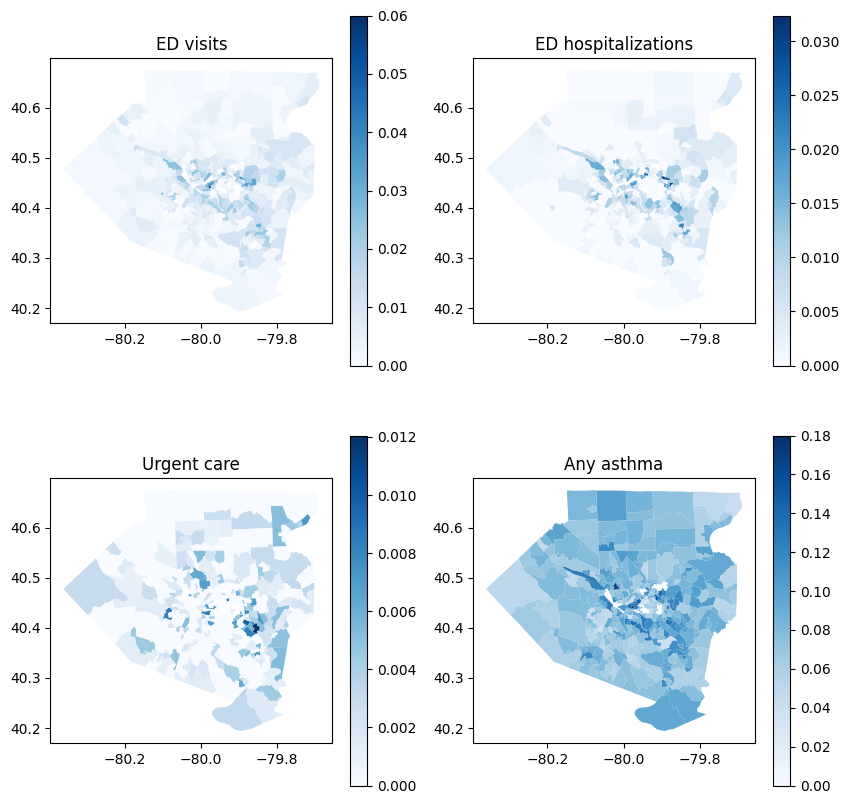

In [5]:
# plot the fraction of children who have at least one asthma encounter types, using Allegheny County geography
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
asthma_gpd.plot(column="ED_visits_frac", cmap="Blues", legend=True, ax=axs[0,0])
axs[0,0].set_title("ED visits")
asthma_gpd.plot(column="ED_hosp_frac", cmap="Blues", legend=True, ax=axs[0,1])
axs[0,1].set_title("ED hospitalizations")
asthma_gpd.plot(column="UC_visits_frac", cmap="Blues", legend=True, ax=axs[1,0])
axs[1,0].set_title("Urgent care")
asthma_gpd.plot(column="Asthma_use_frac", cmap="Blues", legend=True, ax=axs[1,1])
axs[1,1].set_title("Any asthma")

There is a tempting pattern of higher asthma encounters in the southeast region of Allegheny County. As we'll see below, this is also an area of higher PM 2.5 concentration from industrial activity.

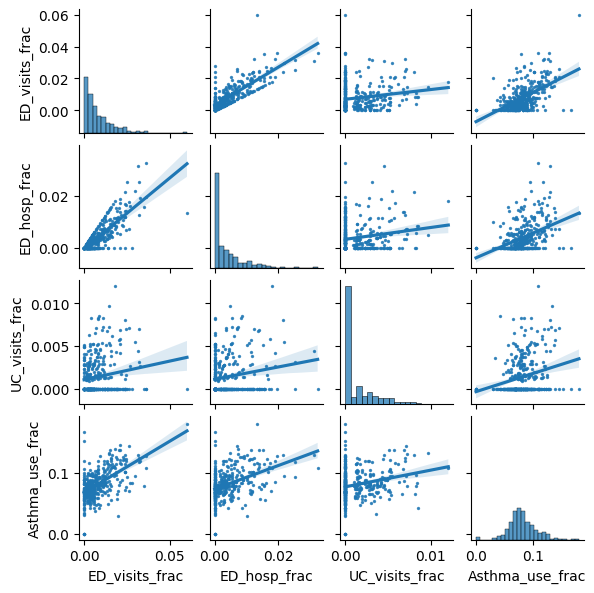

In [6]:
# plot relationships among our outcome variables
# this doesn't really affect the statistics later on, it's mostly context
sns.pairplot(asthma[dep_vars], height=1.5, kind="reg", plot_kws={"scatter_kws":{"s": 2}})

Fortunately, emergency department and urgent care visits are fairly rare. We see a strong positive skew to the distributions of these data. Overall asthma use is much more common, and has a much more normal distribution, than the emergency department or urgent care variables.

Interestingly, we actually see a higher fraction of children with emergency department visits and hospitalizations than we do urgent care visits. I would have assumed that higher acuity care would be rarer than lower acuity. I suspect this difference has more to do with socio-economics than it does medicine, and this hypothesis is supported with data below.

There are, unsurprisingly, positive correlations between all pairs of asthma variables.

## Air quality and demographics

The EPA's EJ Screen dataset includes PM 2.5 concentration estimations averaged annually and over census block groups. Census tracts are composed of unions of census block groups, so it is straightforward to average the PM 2.5 concentrations over census tracts to match the localization of the asthma data.

The EJ Screen data includes several variables related to air quality, including
- PM 2.5 `PM25`
- ozone `O3`
- nitrogen dioxide (but not for 2017)
- diesel particulate matter (a subset of PM 2.5) `dpm`
- traffic proximity `traffic`
- toxic releases to air

I am focusing on PM 2.5, diesel particulate matter, and traffic proximity, since these are [known risk factors in the development of childhood asthma](https://pmc.ncbi.nlm.nih.gov/articles/PMC7503605/). Nitrogen dioxide is also a known risk factor, but that data is not available for 2017.

I am also using the EPA's demographic data, specifically
- fraction of residents who are low income, i.e. within 2x of the federal poverty line `lowincome`
- fraction of residents who are people of color `poc`
  
This demographic data is compiled by the EPA from the American Community Survey (ACS).

In [7]:
# import the EPA's air quality and demographic data, localized to census tracts
aq = pd.read_csv(data_dir  / "epa_ej" / "2017_tract.csv")

In [8]:
# add on the 2010 census tract geography for plotting
aq_gpd = tracts.merge(aq, left_on="GEOID10", right_on="ID", how="right", validate="1:1")

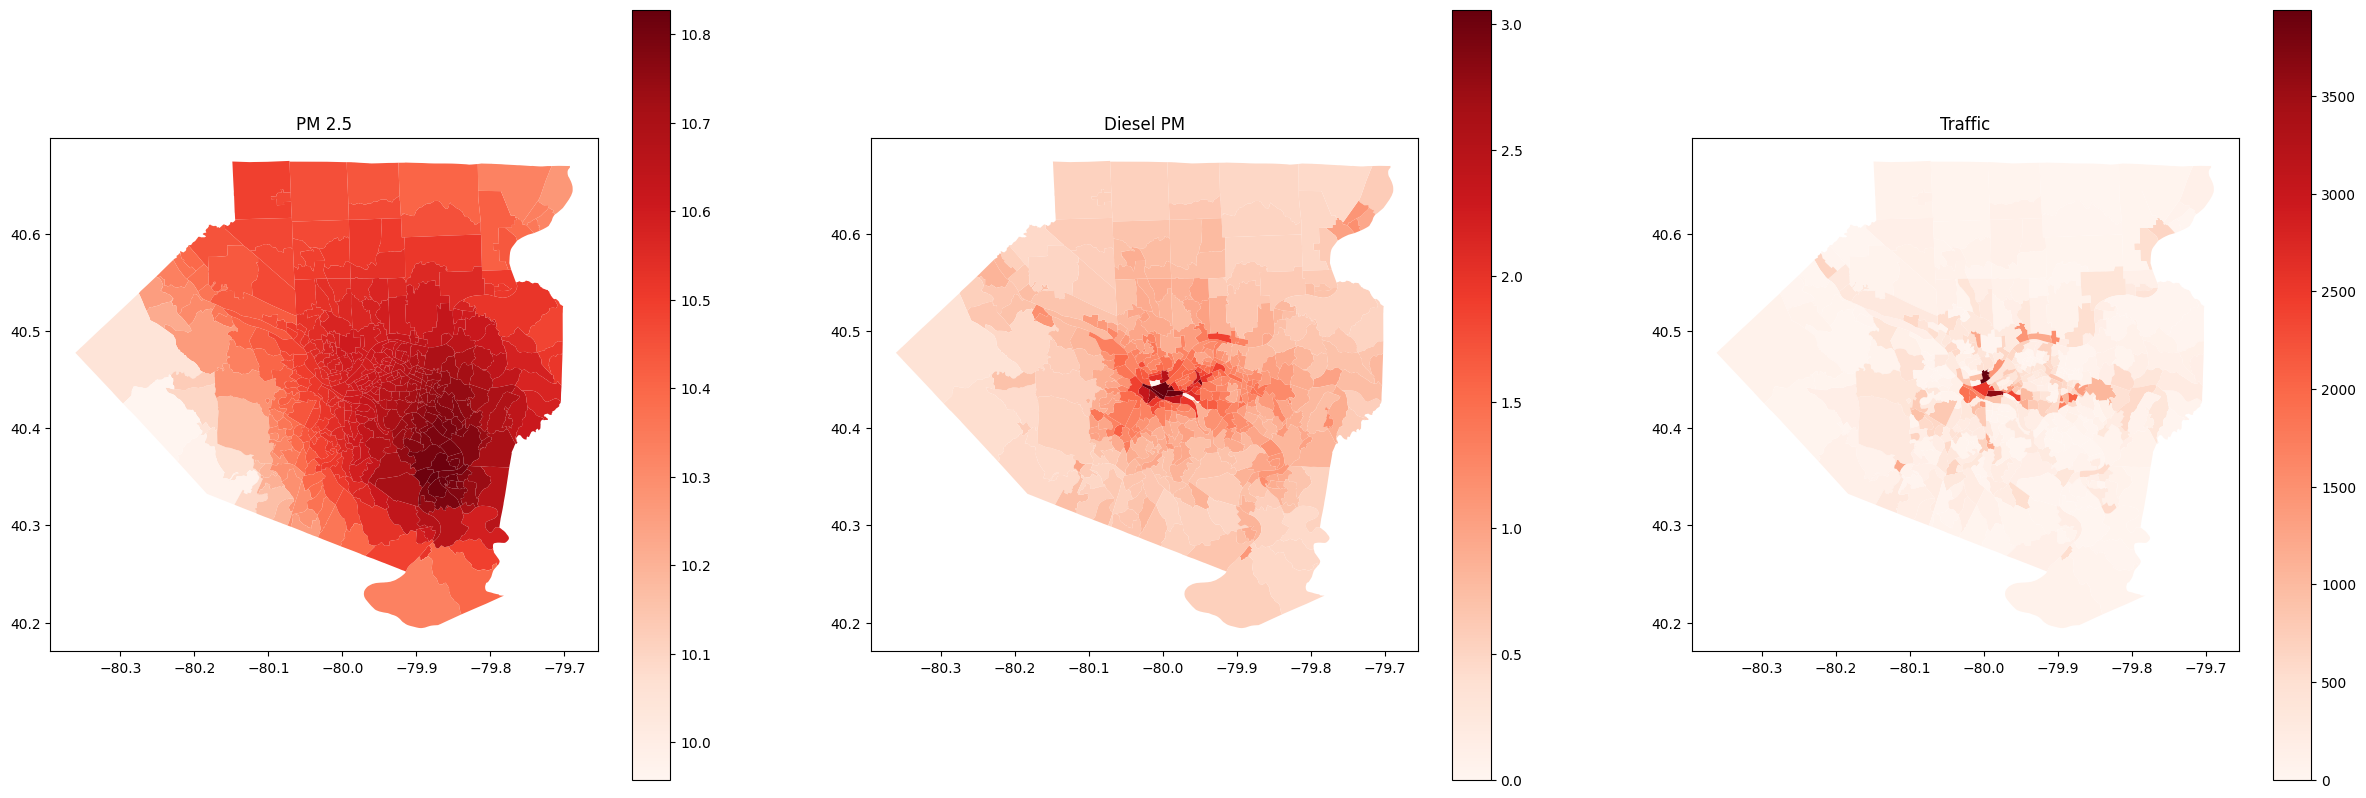

In [9]:
# plots of air quality related measures
fig, axs = plt.subplots(1, 3, figsize=(30, 10))
aq_gpd.plot(column="PM25", cmap="Reds", legend=True, ax=axs[0])
axs[0].set_title("PM 2.5")
aq_gpd.plot(column="dpm", cmap="Reds", legend=True, ax=axs[1])
axs[1].set_title("Diesel PM")
aq_gpd.plot(column="traffic", cmap="Reds", legend=True, ax=axs[2])
axs[2].set_title("Traffic")

# save the primary independent variables
indep_vars = ["PM25", "dpm", "traffic"]

- PM 2.5 has higher concentrations in the southeastern portion of Allegheny County. This corresponds to heavy industry in the Mon Valley, e.g. Clairton Coke Works, which are known emitters of PM 2.5.
- Diesel PM and traffic proximity seem to be concentrated near downtown Pittsburgh.

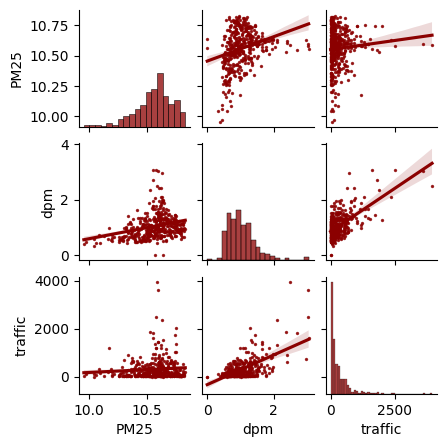

In [10]:
# plot relationships among the air quality variables
sns.pairplot(aq[indep_vars], height=1.5, kind="reg", 
             plot_kws={"scatter_kws":{"s": 2}, "color": "darkred"}, diag_kws={"color": "darkred"})

PM 2.5 and diesel PM have somewhat skew distributions, and distance to traffic is quite positively skewed. 

Diesel PM and traffic proximity are positively correlated, as expected from the regional plots above (and from expecting that the diesel PM originates in road traffic). Because these variables are strongly correlated, and diesel PM has a more normal distribution, I expect that I will want to use only diesel PM in my models. For now, I will keep traffic proximity in the models, to see how it does.

PM 2.5 is positively correlated with diesel PM, but not with traffic proximity.

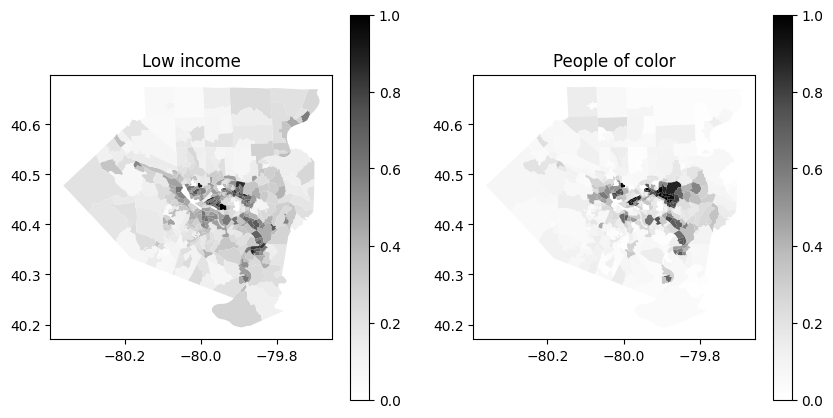

In [11]:
# plots of demographic measures
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
aq_gpd.plot(column="lowincome", cmap="Greys", legend=True, ax=axs[0])
axs[0].set_title("Low income")
aq_gpd.plot(column="poc", cmap="Greys", legend=True, ax=axs[1])
axs[1].set_title("People of color")

# save the demographic variables for later
demo_vars = ["lowincome", "poc"]

Southeastern Allegheny County appears to have more residents who are low income, as well as more residents who are people of color.

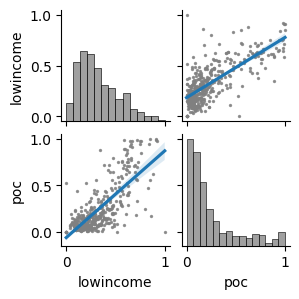

In [12]:
# plot relationships between the demographic variables
sns.pairplot(aq[demo_vars], height=1.5, kind="reg", 
             plot_kws={"scatter_kws":{"s": 2, "color": "grey"}}, diag_kws={"color": "grey"})

As (unfortunately) expected, there is a strong correlation between fraction POC and fraction low income residents.

## Asthma vs air quality: linear regression

In [13]:
# merge asthma data with air quality / demographic data
df = asthma.merge(aq, left_on="Census_tract", right_on="ID", how="left", validate="1:1")
# put the geometry back in
df = tracts.merge(df, right_on="Census_tract", left_on="GEOID10", validate="1:1")
# add a column of ones to act as the intercept
df["intercept"] = 1

### Without controlling for demographics

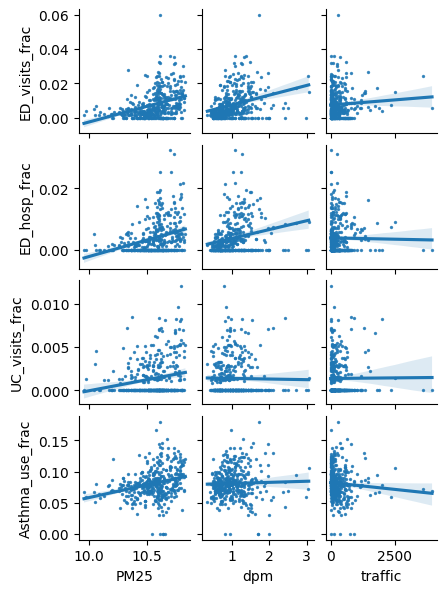

In [14]:
# quick picture of relationships between outcomes and air quality
sns.pairplot(df[dep_vars + indep_vars], x_vars=indep_vars, y_vars=dep_vars, 
             kind="reg", plot_kws={"scatter_kws":{"s": 2}}, height=1.5)

In [15]:
# linear regression, predicting asthma encounter fraction using average air quality measures as sole predictors
# these are the same as the regressions in the images above
all_res = list()
for indep in indep_vars:
    ols_res = dict()
    for dep in dep_vars:
        mod = sm.OLS(df[dep], df[[indep] + ["intercept"]])
        res = mod.fit()
        ols_res[dep] = res
    all_res.append(ols2df(ols_res)[["coef", "std err", "p", "R2"]])
pd.concat(all_res).style.pipe(p_col_style)

,,coef,std err,p,R2
dep_var,indep_var,,,,
ED_visits_frac,PM25,0.018370,0.002406,0.000,0.129703
ED_hosp_frac,PM25,0.010794,0.001647,0.000,0.098919
UC_visits_frac,PM25,0.002558,0.000678,0.000,0.035112
Asthma_use_frac,PM25,0.040760,0.007527,0.000,0.069766
ED_visits_frac,dpm,0.005643,0.000901,0.000,0.091256
ED_hosp_frac,dpm,0.002869,0.000619,0.000,0.052094
UC_visits_frac,dpm,-0.000073,0.000253,0.773,0.000214
Asthma_use_frac,dpm,0.001756,0.002857,0.539,0.000965
ED_visits_frac,traffic,0.000001,0.000001,0.192,0.004341


Linear regression shows a significant relationship between PM 2.5 and all asthma encounter fractions, with worse air quality associated with more children having asthma-related medical encounters.

Diesel PM is associated with more children with emergency department visits and hospitalizations, but not lower acuity care. This result may reflect that diesel PM is associated with acute respiratory distress more than chronic conditions. (TODO is this supported by the literature?)

Traffic proximity isn't significantly associated with any outcome, Recalling the distribution of the traffic data, I also tried using the log of the traffic proximity, to generate a more normally distributed variable. (TODO make an aux notebook) That did improve regression results, but not enough to justify including traffic proximity in the following models.

What if we include PM 2.5 and diesel PM as predictors together? We will lose power, and we previously saw that PM 2.5 and diesel PM are (TODO significantly) positively correlated, so the standard errors will be inflated. However, I am interested to know in particular if the predictive power of PM 2.5 observed for the emergency department encounters comes only from association with higher diesel PM.

In [16]:
indep_vars = ["PM25", "dpm"]

for dep in dep_vars:
    mod = sm.OLS(df[dep], df[indep_vars + ["intercept"]])
    res = mod.fit()
    ols_res[dep] = res

ols2df(ols_res)[["coef", "std err", "p", "R2"]].style.pipe(p_col_style)

We reproduce the simple linear regression results, confirming the results that
- PM 2.5 is predictive of all 4 outcomes
- diesel PM is predictive of emergency outcomes, but not urgent care or asthma generally

Note that, due to the collinearity between PM 2.5 and diesel PM, the signficance of these results is conservative.

Going forward, we will include diesel PM as a predictor only for the emergency department outcomes.

In [17]:
indep_to_use = {"ED_visits_frac": ["PM25", "dpm"],
                "ED_hosp_frac": ["PM25", "dpm"],
                "UC_visits_frac": ["PM25"],
                "Asthma_use_frac": ["PM25"]}

I want to note here that the largest coefficient of determination R2 that we see for these models including only air quality is 0.17. In other words, we can at best cover 17% of the variation in asthma outcomes using air quality alone.

We are about to see below that, using demographics alone, we can cover 47%.

### Collinearity check

I want to see if the results above are robust to controlling for demographics. I do not suspect a causal relationship between demographics and asthma incidence. However,
1. I do suspect a causal relationship between demographics and access to healthcare
2. My deeper interest is in behavioral health, which has more complex demographic related effects, so I want to pilot controlling for demographics here.

Before I do that, I'm interested to look at the relationship between demographics and air quality. I anticipate that neighborhoods with larger proportions of low income and POC residents have worse air quality, for socioeconomic reasons. If that is true, I will be working with 4 predictors that I expect to be highly collinear, which will make my regression results much harder to interpret.

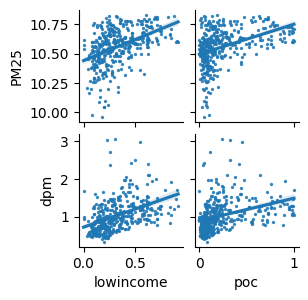

In [18]:
# quick picture of relationships between demographics and air quality
sns.pairplot(df[demo_vars + indep_vars], x_vars=demo_vars, y_vars=indep_vars, 
             kind="reg", plot_kws={"scatter_kws":{"s": 2}}, height=1.5)

There are significant relationships between the air quality measures and the demographic measures (regression coefficients and p-values not shown). Unfortunately (again) we see higher air pollution in areas with higher proportions of POC and low-income residents.

We've now seen that all 4 independent variables are significantly positively correlated with each other. Controlling for demographics will require fitting linear regression models with all these variables together. I want to know whether the standard errors are likely to be inflated by collinearity, since I am relying on the standard errors to distinguish significant predictors of asthma outcomes.

I use the VIF to check.

In [19]:
cols = ["PM25", "dpm", "lowincome", "poc"]
for idx in range(len(cols)):
    val = variance_inflation_factor(df[cols], idx)
    print(cols[idx], val)

PM25 7.805840271300308
dpm 8.44092870162693
lowincome 10.360421525696621
poc 4.833696233666254


Using the standard cutoff of VIF = 5, 3/4 of the independent variables are highly collinear with the other variables, inflating the standard errors and making the resulting p-values unreliable.

Note that this is also true of the analyses using PM 2.5 without diesel PM, due to the collinearity in the low income variable:

In [20]:
cols = ["PM25", "lowincome", "poc"]
for idx in range(len(cols)):
    val = variance_inflation_factor(df[cols], idx)
    print(cols[idx], val)

PM25 4.164822439358602
lowincome 9.628665545617753
poc 4.830049297361873


### Controlling for demographics

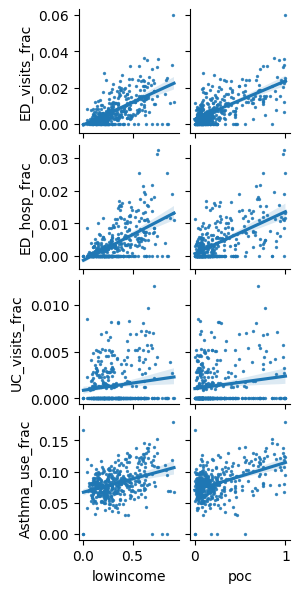

In [21]:
# quick picture of relationships between outcomes and demographics
sns.pairplot(df[dep_vars + demo_vars], x_vars=demo_vars, y_vars=dep_vars, 
             kind="reg", plot_kws={"scatter_kws":{"s": 2}}, height=1.5)

In [22]:
# reproduce the regressions in the figure above, using the demographic variables on their own as predictors
all_res = list()
for indep in demo_vars:
    ols_res = dict()
    for dep in dep_vars:
        mod = sm.OLS(df[dep], df[[indep] + ["intercept"]])
        res = mod.fit()
        ols_res[dep] = res
    all_res.append(ols2df(ols_res)[["coef", "std err", "p", "R2"]])
pd.concat(all_res).style.pipe(p_col_style)

,,coef,std err,p,R2
dep_var,indep_var,,,,
ED_visits_frac,lowincome,0.024718,0.001639,0.000,0.367891
ED_hosp_frac,lowincome,0.015653,0.001138,0.000,0.325926
UC_visits_frac,lowincome,0.001539,0.000546,0.005,0.019911
Asthma_use_frac,lowincome,0.042579,0.005852,0.000,0.119263
ED_visits_frac,poc,0.021085,0.001187,0.000,0.446618
ED_hosp_frac,poc,0.012850,0.000854,0.000,0.366452
UC_visits_frac,poc,0.001328,0.000422,0.002,0.024757
Asthma_use_frac,poc,0.044322,0.004275,0.000,0.215609


In [23]:
# linear regression, predicting asthma encounter fraction using both demographics together
ols_res = dict()
for col in dep_vars:
    mod = sm.OLS(df[col], df[demo_vars + ["intercept"]])
    res = mod.fit()
    ols_res[col] = res
ols2df(ols_res)[["coef", "std err", "p", "R2"]].style.pipe(p_col_style)

All the demographic variables are also significant predictors of all asthma encounter fractions when considered individually. Higher proportions of low income and PoC residents are predictive of higher childhood asthma medical encounter rates. The low income variable alone accounts for 37% of the variation in ED visits, and 33% of the variation in ED hospitalizations. PoC accounts for 45% and 37% of those same variables, respectively. 

When considering proportions of low income and PoC residents together, both are predictive of both ED outcomes, neither is predictive of urgent care, and only PoC is predictive of overall asthma use. Together, the demographic variables account for 47% of the variation in ED visits, and 39% in ED hospitalizations. 

Recall that air quality alone only covered 17% and 11% of the variation in ED visits and hospitalizations. These results already suggest that, even if air quality remains a significant predictor of ED outcomes when controlling for demographics, the demographic variables seem to be driving ED outcomes more than air quality.

Does air quality remain predictive of asthma outcomes when controlling for demographics? Or are demographics the driving predictor of asthma outcomes while being correlated with air quality? 

In [24]:
# linear regression, predicting asthma encounter fraction using air quality as well as demographics
ols_res = dict()
for col in dep_vars:
    mod = sm.OLS(df[col], df[indep_to_use[col] + demo_vars + ["intercept"]])
    res = mod.fit()
    ols_res[col] = res
ols2df(ols_res)[["coef", "std err", "p", "R2"]].style.pipe(p_col_style)

For emergency department visits and hospitalizations, PM 2.5 and diesel PM are no longer significant predictors when low income and PoC covariates are included. However, higher fractions of both low income and PoC residents predict higher rates of emergency department utilization for childhood asthma. I suspect this result reflects that lower income residents and PoC residents have less access to non-emergency medical services than higher income and white residents. These residents therefore are more likely to be seen in the emergency department rather than urgent or primary care. They may have higher rates of ED hospitalization due to lack of access to preventative care leading to higher acuity cases.

PM 2.5 remains a significant predictor of urgent care visits and a marginal predictor of overall medical encounters related to childhood asthma. In areas with higher average annual concentrations of PM 2.5, a higher fraction of children receive medical attention for asthma, even when controlling for low income and PoC resident proportions. 

However, as discussed above, all these variables are highly collinear. Are we missing significant results due to variance inflation? 

### Reducing collinearity
I tried several methods of reducing the collinearity in the data by combining the air quality and demographic variables separately. The result was to use the mean to combine air quality data (for ED outcomes only) and PCA to combine demographic data. These combination variables are not collinear with each other.

For the details on this process, see the notebook Appendix (TODO link).

In [25]:
# compute combined variables

# mean for air quality data
# scale PM 2.5 and diesel before combining, because they are on very different scales
df[["PM25_scale", "dpm_scale"]] = StandardScaler().fit_transform(df[["PM25", "dpm"]])
df["PM25_dpm_mean"] = df[["PM25_scale", "dpm_scale"]].mean(axis=1)

# PCA for demographic variables
pca_demo = PCA(n_components=1)
pca_demo.fit(df[["lowincome", "poc"]])
print("Demographics PCA explained variance: {}".format(pca_demo.explained_variance_ratio_[0].round(3)))
df["poc_lowincome_pca"] = pca_demo.transform(df[["lowincome", "poc"]])

Demographics PCA explained variance: 0.896


In [26]:
# combined variables are no longer collinear
cols = ["PM25_dpm_mean", "poc_lowincome_pca"]
for idx in range(len(cols)):
    val = variance_inflation_factor(df[cols], idx)
    print(cols[idx], val)

PM25_dpm_mean 1.3891119112222916
poc_lowincome_pca 1.3891119112222916


In [27]:
combo_indep_vars = {"ED_visits_frac": ["PM25_dpm_mean", "poc_lowincome_pca"],
                    "ED_hosp_frac": ["PM25_dpm_mean", "poc_lowincome_pca"],
                    "UC_visits_frac": ["PM25", "poc_lowincome_pca"],
                    "Asthma_use_frac": ["PM25", "poc_lowincome_pca"]}

ols_res = dict()
for col in dep_vars:
    mod = sm.OLS(df[col], df[combo_indep_vars[col] + ["intercept"]])
    res = mod.fit()
    ols_res[col] = res
ols2df(ols_res)[["coef", "std err", "p", "R2"]].style.pipe(p_col_style)

The results with non-collinear combined variables are similar to the previous results. Air quality is not a significant predictor of ED outcomes, but demographics are. PM 2.5 is a significant predictor of urgent care visits, but demographics aren't. The only difference is that the marginally significant result for PM 2.5 in predicting general asthma use is now not significant, while demographics remain significant.

These results support the conclusion that, in this dataset:
- Demographics predict ED asthma outcomes and overall asthma use, but air quality does not
- PM 2.5 predicts urgent care asthma outcomes, but demographics do not

## Spatial autocorrelation

The linear regressions above assume that observations are independent of each other. However, I have good reason to believe that they are not, since there are apparent spatial structures in the variables. Particularly for the air quality measures, I would be suprised if there wasn't spatial autocorrelation in the data: areas close to each other are expected to have more similar air than areas further away.

What effect would spatial autocorrelation have on the results and conclusions?

- In the predictors/independent variables, autocorrelation may lead to underestimation of coefficient confidence intervals, causing predictors to appear significant that actually aren't. I am in esssence "double counting" the effect of each autocorrelated predictor, because measurements from adjacent census tracts are similar to each other.
- Autocorrelation of the outcomes/dependent variables may lead to a biased (aka just plain wrong) estimates of model coefficients. This bias arises because the OLS model cannot incorporate information about how the outcome in one region affects the outcome in other regions.

For transparency: I learned about modeling with spatially autocorrelated data for this investigation, primarily from 
- [Geographic Data Science with Python](https://geographicdata.science/book/notebooks/11_regression.html#)
- [Spatial Methods in Community Research](https://crd230.github.io/lab8.html#Spatial_lag_model)
- [the PySAL documentation](https://pysal.org/docs/users/)


### Spatial weights

I first want to determine, statistically, if our variables are spatially autocorrelated. To do that, I need to decide what my spatial weighting scheme is. There are many options to choose from, broadly
- Contiguity based (e.g. Queen, Rook, and Bishop)
- Distance based (e.g. KNN, distance thresholds, and kernel weights)
- Block based (e.g. all regions with a given attribute are weighted together)

In this dataset, the conclusions of the spatial autocorrelation aware analyses are dependent on the choice of spatial weights (TODO see notebook A Deeper Dive into the Spatial Lag). So I need to be careful about how I choose the spatial weights.

- PM 2.5 data shows continuous variability across Allegheny County, spreading from a peak in the Mon Valley. This observation matches the physics of how contaminants disperse in air.* From this, I expect that a continuous distance based spatial lag would be best, probably one based on a Gaussian kernel.
- Similarly, diesel PM could be modeled using a Gaussian kernel model, although its spatial spread is much smaller, so a KNN model might also work well.
- Based on both the maps as well as observations of neighborhoods, I suspect that a contiguity measure would work best for the demographic data.

After testing a range of spatial weights, I decided to use
- PM 2.5: Gaussian with bandwidth 15 miles
- Diesel PM: Gaussian with bandwidth 5 miles
- Low income and PoC fraction: Queen's contiguity

*This statement is actually backwards, since the PM 2.5 "data" is the output of an atmospheric dispersion model.

In [43]:
RADIUS_EARTH_MILES = 3959
weights_dict = {"queen": [weights.Queen, dict()],
                "Gaussian_5": [weights.Kernel, {"function": "gaussian", "bandwidth": 5, "distance_metric": "arc", "radius": RADIUS_EARTH_MILES}],
                "Gaussian_15": [weights.Kernel, {"function": "gaussian", "bandwidth": 15, "distance_metric": "arc", "radius": RADIUS_EARTH_MILES}],
               }
lag_dict = {"PM25": "Gaussian_15",
            "dpm": "Gaussian_5",
            "PM25_dpm_mean": "Gaussian_5", # TODO
            "lowincome": "queen",
            "poc": "queen",
            "poc_lowincome_pca": "queen", # TODO
           }

In [45]:
# compute Moran's I to determine spatial autocorrelation
res_dict = {}
for col in ["PM25", "dpm", "PM25_dpm_mean", "lowincome", "poc", "poc_lowincome_pca"]:
    weight_class = weights_dict[lag_dict[col]][0]
    weight_kwargs = weights_dict[lag_dict[col]][1]
    # spatial lag weights
    w = weight_class.from_dataframe(df, use_index=False, **weight_kwargs)
    # standardize by rows to use averages instead of sums
    w.transform = "R"
    moran = Moran(df[col], w)
    res_dict[col] = {"I": moran.I, "p": moran.p_sim}
res = pd.DataFrame(res_dict).transpose()
res

,I,p
PM25,0.144988,0.001
dpm,0.473050,0.001
PM25_dpm_mean,0.673527,0.001
lowincome,0.553072,0.001
poc,0.652880,0.001
poc_lowincome_pca,0.644815,0.001


All of the predictors are significantly spatially autocorrelated. (The outcomes are also spatially autocorrelated -- see A Deeper Dive into the Spatial Lag.)

One way to handle spatial autocorrelation is to include spatial lag in the model formulation. Spatial lag is essentially a weighted combination of "nearby" data, so the prediction of the outcome in one region explicitly uses data from the area around it.

There are several common ways of incorporating spatial lag:
1. Include pre-computed spatial lags of the independent variables in the linear regression (for independent variable spatial autocorrelation)
    - This technique explicitly models the concept that the outcome in one region is affected by the state in neighboring regions. In our data, that concept might be represented by children moving through multiple nearby regions for school, sports, jobs, etc. We expect people who live in one region to be exposed to air pollution in adjacent regions, and to be more exposed to air pollution in regions that are closer.
2. Include spatial lag in the error term of the linear regression (for independent variable spatial autocorrelation)
    - This technique accounts for the observation that the air pollution data and demographic data are both spatially clustered. We therefore expect the error from OLS to also be spatially clustered, which violates an assumption of OLS. (TODO check that expectation)
3. Include spatial lag of the dependent variable in the linear regression (for dependent variable spatial autocorrelation)
    - This technique explicitly models the concept that the outcome is one region is affected by the outcome in neighboring regions. In this case, that would mean that asthma utilization in one region is affected by the asthma utilization in nearby regions. That doesn't make sense conceptually -- my model interprets the clustering of asthma outcomes as being an effect of the clustering of the independent variables.

Note that method 1 allows for using OLS, but methods 2 and 3 violate the basic assumptions of OLS regression and must be solved differently.

In this notebook, I will be looking at methods 1 and 2, as well as a combination of methods 1 and 2 called a spatial Durbin error model. For my own curiosity, I did try method 3 (see notebook A Deeper Dive into the Spatial Lag), but none of the models showed a significant effect of the spatial lag of the asthma outcome.

### Method 1: spatial lag of independent variables (SLX)

In [37]:
def make_lag(df, col, weight_class, weight_kwargs=dict()):
    # spatial lag weights
    w = weight_class.from_dataframe(df, use_index=False, **weight_kwargs)
    # standardize by rows to use averages instead of sums
    w.transform = "R"
    # compute the spatial lag of column col
    w_col = weights.spatial_lag.lag_spatial(w, df[col])
    w_series = pd.Series(w_col, name="w_{}".format(col), index=df.index)
    return w_series

In [47]:
# compute the spatial lag of all independent variables (air quality + demographics)
# using row-standardized weights defined above
dfx = df.copy()
for col, lag in lag_dict.items():
    new_col = make_lag(df, col, weights_dict[lag][0], weights_dict[lag][1])
    dfx = pd.concat([dfx, new_col], axis=1)

First, we'll consider a model using air quality alone. This isn't our final model, but I wanted to see what spatial lag did for the model without demographics.

In [48]:
# linear regression, predicting asthma encounter fraction using air quality as well as its spatial lag
ols_res = dict()
for col in dep_vars:
    mod = sm.OLS(dfx[col], dfx[indep_to_use[col] + ["w_{}".format(x) for x in indep_to_use[col]] + ["intercept"]])
    res = mod.fit()
    ols_res[col] = res
ols2df(ols_res)[["coef", "std err", "p"]].style.pipe(p_col_style)

PM 2.5 remains a significant predictor of childhood asthma encounters for all cases except urgent care visits. Diesel PM is no longer significant.

What happens when we use spatial lag in the model controlling for demographics?

In [49]:
# linear regression, predicting asthma encounter fraction using air quality as well as its spatial lag
ols_res = dict()
for col in dep_vars:
    mod = sm.OLS(dfx[col], dfx[combo_indep_vars[col] + ["w_{}".format(x) for x in indep_to_use[col]] + ["intercept"]])
    res = mod.fit()
    ols_res[col] = res
ols2df(ols_res)[["coef", "std err", "p"]].style.pipe(p_col_style)

Demographics are now significantly predictive of all asthma outcomes, and air quality is predictive of none. The spatial lag of PM 2.5 is predictive of urgent care visits.

### Method 2: spatial lag of error term

In [51]:
# Spatial lag in the error term, fit using
# general method of moments estimation allowing for heteroskedasticity
#
# This is a general method that allows us to choose the weights used to compute the error term, 
# in this case the same spatial lag weights computed above

# start without controlling for demographics
res_dict = dict()
for dep in dep_vars:
    indep = indep_to_use[dep]
    res = spreg.GM_Error_Het(df[[dep]].values, df[indep].values, w=w, name_y=dep, name_x=indep)
    res_dict[dep] = res
spreg2df(res_dict)[["coef", "std err", "p"]].style.pipe(p_col_style)

As before, air quality is a significant predictor of all measures of childhood asthma, even accounting for the effect of spatial autocorrelation of air quality measures.

The spatial lag error term coefficient `lambda` is also significant for every model except when predicting overall asthma use. This suggests that the spatial autocorrelation of air quality likely did cause underestimation of the confidence intervals in the previous models.

How do these effects hold up to controlling for demographic covariates?

In [ ]:
res_dict = dict()
for dep in dep_vars:
    indep = indep_to_use[dep] + ["lowincome", "poc"]
    res = spreg.GM_Error_Het(df[[dep]].values, df[indep].values, w=w, name_y=dep, name_x=indep)
    res_dict[dep] = res
spreg2df(res_dict)[["coef", "std err", "p"]].style.pipe(p_col_style)

Air quality loses significance as a predictor of ED hospitalizations and overall asthma related encounters. However, the fraction of low income and PoC residents remains significant for ED visits and hospitalizations.

The spatial lag term `lambda` is significant for all outcomes except ED hospitalizations.

Recall that for the original models (without spatial lag), only the urgent care visits and overall asthma use remained significant after controlling for demographics.

What about if we control for spatial autocorrelation in the dependent variables?

In [ ]:
# Spatial lag in the dependent variable, fit using
# general method of moments estimation allowing for dependent variable lag
#
# This is a general method that allows us to choose the weights used to lag the dependent variable,
# in this case the same spatial lag weights computed above

# start without controlling for demographics
res_dict = dict()
for dep in dep_vars:
    indep = indep_to_use[dep]
    res = spreg.GM_Lag(df[[dep]].values, df[indep].values, w=w, name_y=dep, name_x=indep)
    res_dict[dep] = res
spreg2df(res_dict, name_attr="name_z")[["coef", "std err", "p"]].style.pipe(p_col_style)

In [ ]:
res_dict = dict()
for dep in dep_vars:
    indep = indep_to_use[dep] + ["lowincome", "poc"]
    res = spreg.GM_Lag(df[[dep]].values, df[indep].values, w=w, name_y=dep, name_x=indep)
    res_dict[dep] = res
spreg2df(res_dict, name_attr="name_z")[["coef", "std err", "p"]].style.pipe(p_col_style)